# Student Performance Machine Learning Analysis

This notebook uses the cleaned student performance dataset (`student_cleaned.csv`) to build a simple machine learning analysis. The main idea is to see how variables such as study time, attendance, previous scores, motivation, and access to resources relate to the final exam score.

The notebook is divided into three parts:

1. A short exploratory review of the dataset.
2. K-Means clustering to group students with similar profiles.
3. Supervised models to predict the final score and whether a student passed.

For the regression part, the target is `Final_Exam_Score`. For the classification part, I created a `Passed` variable, where students with a final score of 60 or higher are labeled as passing.

## 1. Import Libraries

The imports are grouped here to avoid repeating the same libraries throughout the notebook.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load the Dataset

The file used here is already cleaned, so this notebook starts directly from the prepared version of the data.

In [2]:
df = pd.read_csv("student_cleaned.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 6607
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 567.9 KB


In [4]:
missing_values = df.isna().sum().to_frame("Missing Values")
missing_values["Missing %"] = (df.isna().mean() * 100).round(2)
missing_values

,Missing Values,Missing %
Hours_Studied,0,0.0
Attendance,0,0.0
Parental_Involvement,0,0.0
Access_to_Resources,0,0.0
Extracurricular_Activities,0,0.0
Sleep_Hours,0,0.0
Previous_Scores,0,0.0
Motivation_Level,0,0.0
Internet_Access,0,0.0
Tutoring_Sessions,0,0.0


## 3. Descriptive Statistics

First, I checked the main numerical summaries to get a general sense of the dataset before modeling.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,20.47,5.99,1.1,16.5,20.5,24.5,44.0
Attendance,6607.0,79.98,11.55,60.0,70.0,79.8,90.2,100.0
Sleep_Hours,6607.0,7.19,1.29,4.0,6.3,7.2,8.1,10.0
Previous_Scores,6607.0,74.72,14.45,50.0,62.1,74.6,87.4,100.0
Tutoring_Sessions,6607.0,1.49,1.22,0.0,1.0,1.0,2.0,8.0
Final_Exam_Score,6607.0,60.40,8.74,29.7,54.3,60.4,66.6,95.2


In [6]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Parental_Involvement
Parental_Involvement
Medium    3365
High      1968
Low       1274
Name: count, dtype: int64

Access_to_Resources
Access_to_Resources
Medium    3349
High      1979
Low       1279
Name: count, dtype: int64

Extracurricular_Activities
Extracurricular_Activities
Yes    3988
No     2619
Name: count, dtype: int64

Motivation_Level
Motivation_Level
Medium    3386
Low       1885
High      1336
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    6093
No      514
Name: count, dtype: int64


## 4. Target Variable Review

`Final_Exam_Score` is the main result I want to predict. Its distribution gives a better idea of how spread out the grades are and whether there are many extreme values.

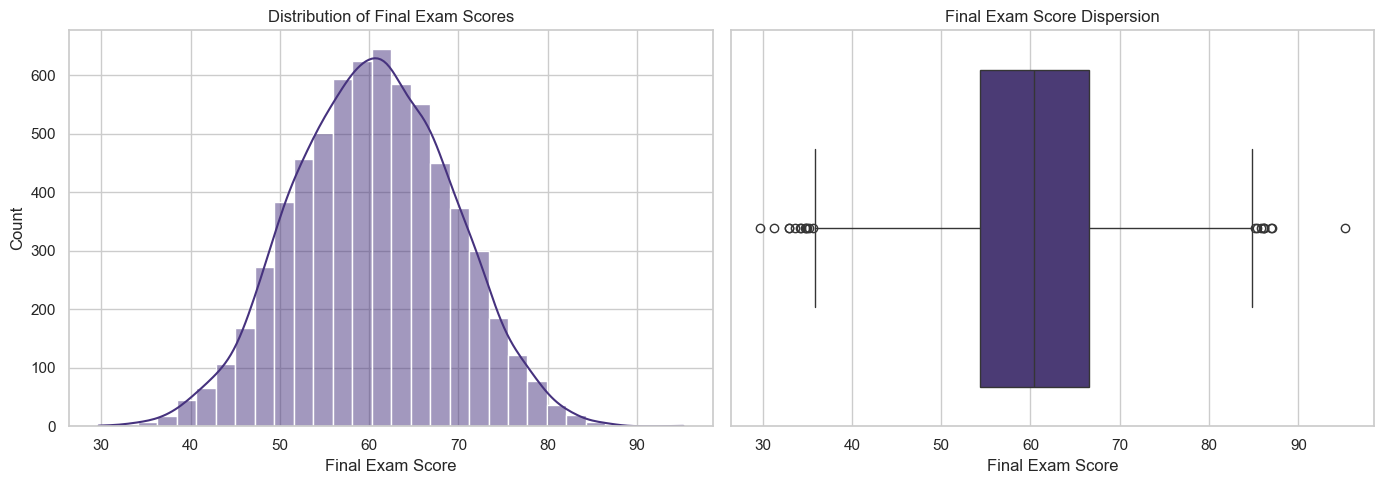

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Final_Exam_Score"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Final Exam Scores")
axes[0].set_xlabel("Final Exam Score")

sns.boxplot(x=df["Final_Exam_Score"], ax=axes[1])
axes[1].set_title("Final Exam Score Dispersion")
axes[1].set_xlabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [8]:
score_summary = df["Final_Exam_Score"].agg(["mean", "median", "std", "min", "max"]).round(2)
score_summary

mean      60.40
median    60.40
std        8.74
min       29.70
max       95.20
Name: Final_Exam_Score, dtype: float64

## 5. Relationship Between Features and Final Score

Before building the models, I looked at how the main variables relate to the final exam score.

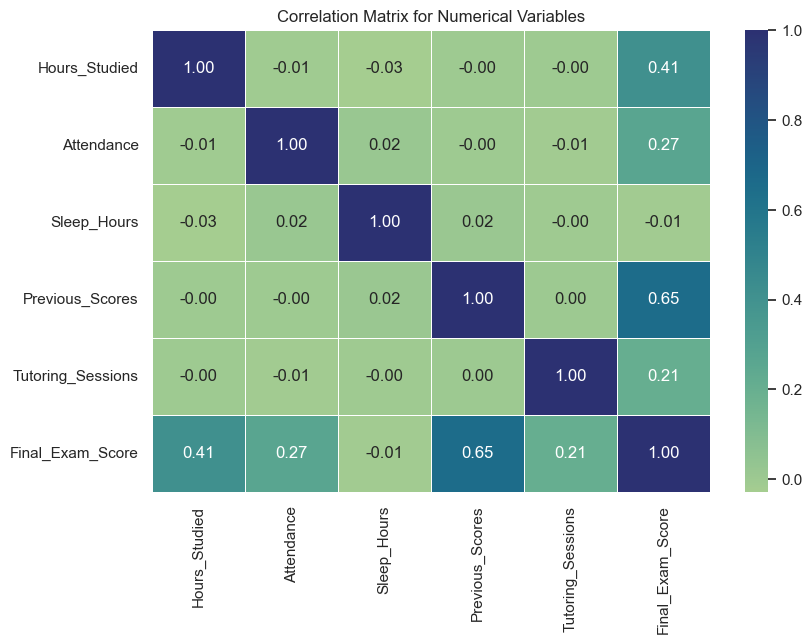

In [9]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="crest", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Numerical Variables")
plt.show()

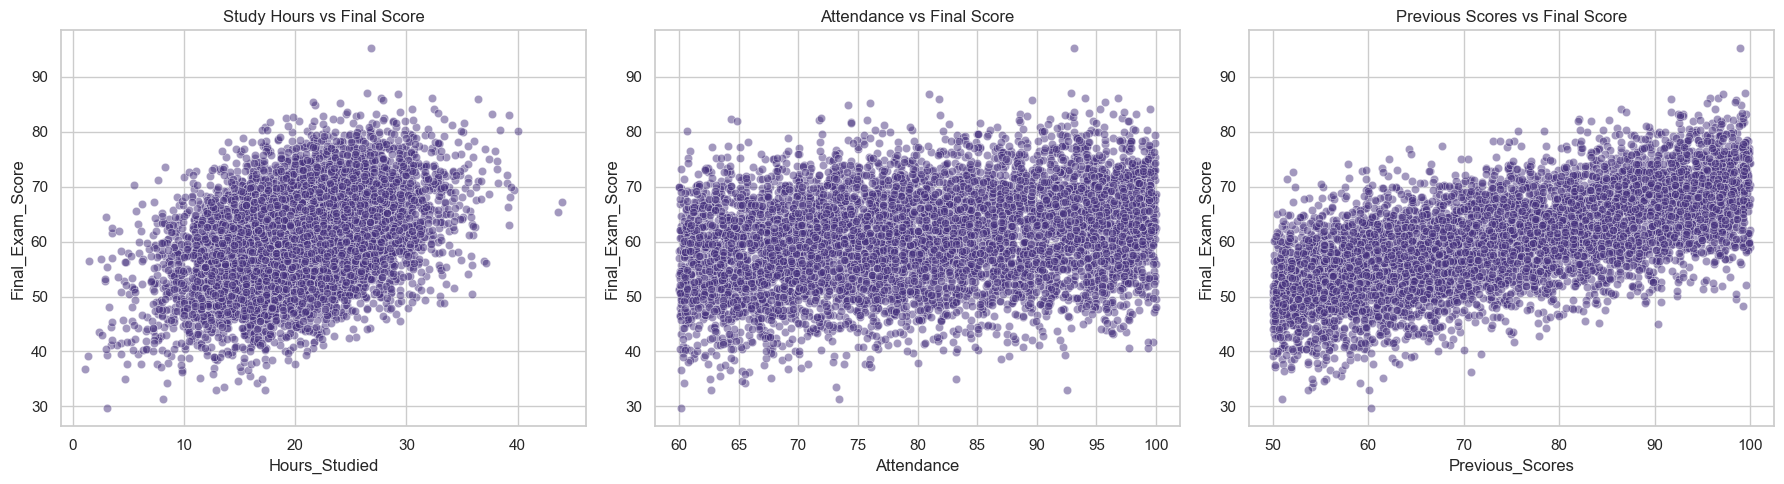

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="Hours_Studied", y="Final_Exam_Score", alpha=0.5, ax=axes[0])
axes[0].set_title("Study Hours vs Final Score")

sns.scatterplot(data=df, x="Attendance", y="Final_Exam_Score", alpha=0.5, ax=axes[1])
axes[1].set_title("Attendance vs Final Score")

sns.scatterplot(data=df, x="Previous_Scores", y="Final_Exam_Score", alpha=0.5, ax=axes[2])
axes[2].set_title("Previous Scores vs Final Score")

plt.tight_layout()
plt.show()

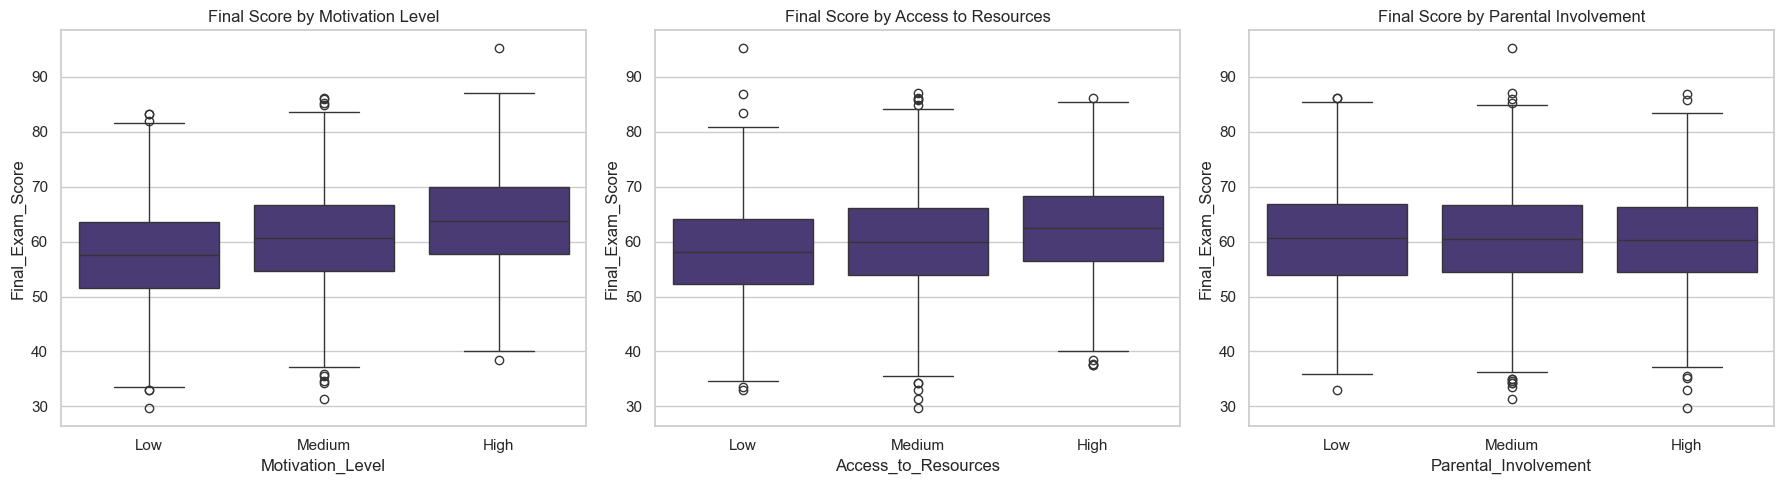

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Motivation_Level", y="Final_Exam_Score", order=["Low", "Medium", "High"], ax=axes[0])
axes[0].set_title("Final Score by Motivation Level")

sns.boxplot(data=df, x="Access_to_Resources", y="Final_Exam_Score", order=["Low", "Medium", "High"], ax=axes[1])
axes[1].set_title("Final Score by Access to Resources")

sns.boxplot(data=df, x="Parental_Involvement", y="Final_Exam_Score", order=["Low", "Medium", "High"], ax=axes[2])
axes[2].set_title("Final Score by Parental Involvement")

plt.tight_layout()
plt.show()

## 6. Feature Engineering

I added a few simple features that may help the models capture student behavior more clearly. These features are created only from the input variables, not from the final score.

- `Study_Attendance_Index`: combines study hours with attendance.
- `Sleep_Distance_From_8`: shows how far each student is from 8 hours of sleep.
- `Tutoring_Any`: separates students who had at least one tutoring session.
- `Passed`: the classification target, based on a final score of 60 or higher.

In [12]:
df_ml = df.copy()

# These engineered features use only predictor variables, not the final score.
df_ml["Study_Attendance_Index"] = df_ml["Hours_Studied"] * (df_ml["Attendance"] / 100)
df_ml["Sleep_Distance_From_8"] = (df_ml["Sleep_Hours"] - 8).abs()
df_ml["Tutoring_Any"] = (df_ml["Tutoring_Sessions"] > 0).astype(int)
df_ml["Passed"] = (df_ml["Final_Exam_Score"] >= 60).astype(int)

df_ml.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score,Study_Attendance_Index,Sleep_Distance_From_8,Tutoring_Any,Passed
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3,19.7870,0.6,1,0
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4,12.5292,1.3,1,0
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8,24.0096,0.0,0,1
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0,26.2256,1.7,1,1
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7,17.4765,1.8,1,1


In [14]:
pass_distribution = df_ml["Passed"].value_counts(normalize=True).rename({0: "Not Passed", 1: "Passed"})
pass_distribution.to_frame("Share").style.format({"Share": "{:.2%}"})

,Share
Passed,
Passed,52.17%
Not Passed,47.83%


## 7. Modeling Setup

For the models, I removed `Final_Exam_Score` from the feature set because it is the regression target. I also removed `Passed` because it is created from the final score.

In [15]:
regression_target = "Final_Exam_Score"
classification_target = "Passed"

feature_columns = [
    column
    for column in df_ml.columns
    if column not in [regression_target, classification_target]
]

X = df_ml[feature_columns]
y_regression = df_ml[regression_target]
y_classification = df_ml[classification_target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Study_Attendance_Index', 'Sleep_Distance_From_8', 'Tutoring_Any']
Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access']


In [16]:
def make_one_hot_encoder():
    """Keep compatibility with different scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", make_one_hot_encoder(), categorical_features),
        ]
    )

## 8. Unsupervised Learning: K-Means Clustering

I used K-Means to group students with similar patterns. The final exam score is not used to create the clusters; it is only checked afterward to understand how each group performed.

In [17]:
cluster_preprocessor = make_preprocessor()
X_cluster = cluster_preprocessor.fit_transform(X)

cluster_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    cluster_scores.append(
        {
            "k": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(
                X_cluster,
                labels,
                sample_size=min(2000, X_cluster.shape[0]),
                random_state=42,
            ),
        }
    )

cluster_scores = pd.DataFrame(cluster_scores)
cluster_scores

,k,Inertia,Silhouette
0,2,60782.419954,0.114092
1,3,53060.680509,0.135228
2,4,48233.038931,0.131519
3,5,46195.829710,0.110465
4,6,44643.935242,0.105478
5,7,42894.069812,0.108238
6,8,41690.171014,0.103307


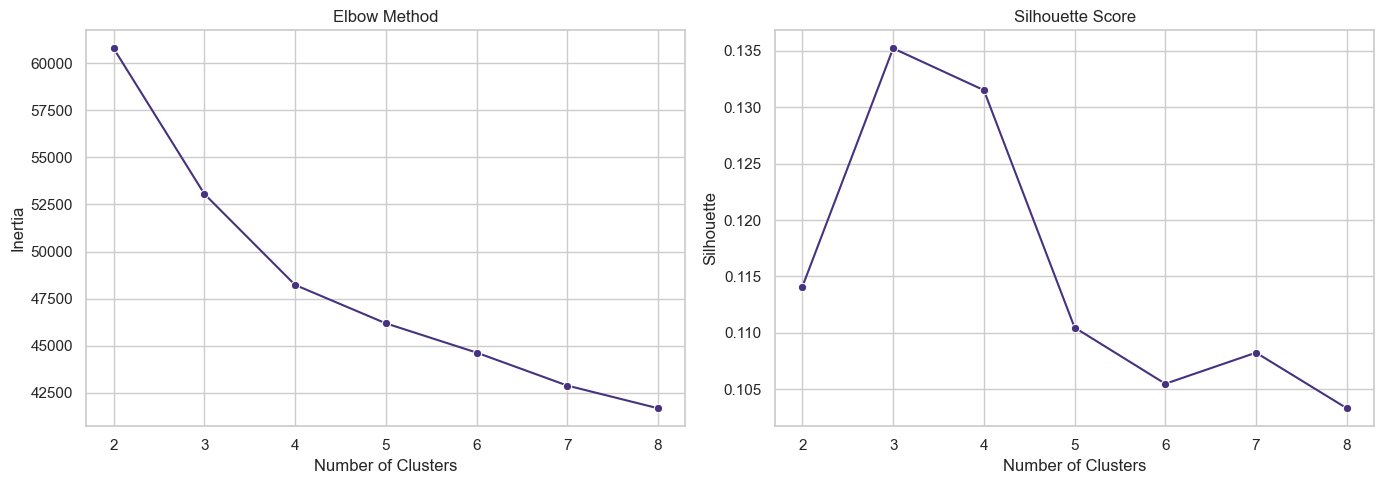

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_scores, x="k", y="Inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=cluster_scores, x="k", y="Silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [19]:
best_k = int(cluster_scores.sort_values("Silhouette", ascending=False).iloc[0]["k"])
print(f"Selected number of clusters: {best_k}")

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml["Student_Profile"] = final_kmeans.fit_predict(X_cluster)

df_ml[["Student_Profile", "Final_Exam_Score"]].head()

Selected number of clusters: 3


,Student_Profile,Final_Exam_Score
0,1,54.3
1,2,59.4
2,0,63.8
3,1,61.0
4,1,60.7


In [20]:
cluster_profile_numeric = (
    df_ml.groupby("Student_Profile")
    .agg(
        Students=("Final_Exam_Score", "count"),
        Avg_Final_Score=("Final_Exam_Score", "mean"),
        Avg_Hours_Studied=("Hours_Studied", "mean"),
        Avg_Attendance=("Attendance", "mean"),
        Avg_Previous_Scores=("Previous_Scores", "mean"),
        Avg_Tutoring_Sessions=("Tutoring_Sessions", "mean"),
        Pass_Rate=("Passed", "mean"),
    )
    .round(2)
)

cluster_profile_numeric

,Students,Avg_Final_Score,Avg_Hours_Studied,Avg_Attendance,Avg_Previous_Scores,Avg_Tutoring_Sessions,Pass_Rate
Student_Profile,,,,,,,
0,1472,58.18,20.46,79.82,74.99,0.00,0.43
1,2391,64.64,24.96,84.97,74.25,1.91,0.71
2,2744,57.90,16.57,75.71,74.98,1.92,0.41


In [21]:
cluster_profile_categorical = (
    df_ml.groupby("Student_Profile")[categorical_features]
    .agg(lambda values: values.mode().iloc[0])
)

cluster_profile_categorical

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access
Student_Profile,,,,,
0,Medium,Medium,Yes,Medium,Yes
1,Medium,Medium,Yes,Medium,Yes
2,Medium,Medium,Yes,Medium,Yes


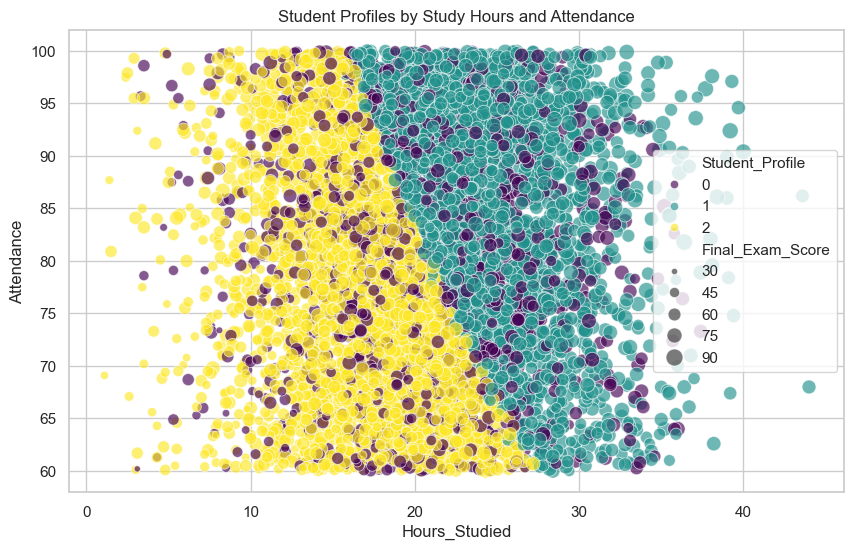

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml,
    x="Hours_Studied",
    y="Attendance",
    hue="Student_Profile",
    size="Final_Exam_Score",
    sizes=(20, 160),
    alpha=0.65,
    palette="viridis",
)
plt.title("Student Profiles by Study Hours and Attendance")
plt.show()

### Clustering Interpretation

The clusters can be read as student profiles. They are not fixed labels, but they help compare groups with different study habits, attendance levels, and academic background.

In this dataset, the stronger profiles are generally the ones with better attendance, more study consistency, and stronger previous scores.

## 9. Supervised Learning: Regression

The regression models predict the actual value of `Final_Exam_Score`. I included a simple baseline model so the real models can be compared against a basic average prediction.

In [23]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42,
)

regression_models = {
    "Baseline Mean": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", DummyRegressor(strategy="mean")),
        ]
    ),
    "Linear Regression": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest Regressor": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

regression_results = []

for model_name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)

    regression_results.append(
        {
            "Model": model_name,
            "R2": r2_score(y_test_reg, predictions),
            "MAE": mean_absolute_error(y_test_reg, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_test_reg, predictions)),
        }
    )

regression_results = pd.DataFrame(regression_results).sort_values("RMSE")
regression_results.round(4)

,Model,R2,MAE,RMSE
1,Linear Regression,0.7913,3.2320,4.0253
2,Random Forest Regressor,0.7605,3.4228,4.3128
0,Baseline Mean,-0.0004,7.1473,8.8143


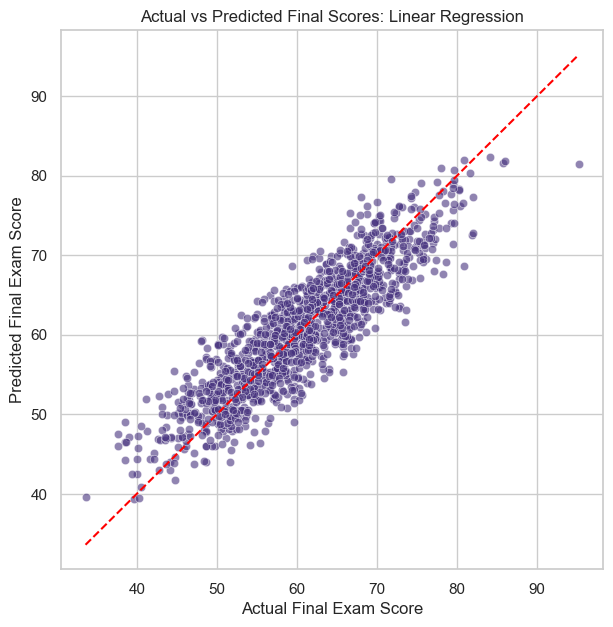

In [24]:
best_regression_name = regression_results.iloc[0]["Model"]
best_regression_model = regression_models[best_regression_name]

regression_predictions = best_regression_model.predict(X_test_reg)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_reg, y=regression_predictions, alpha=0.6)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="red",
    linestyle="--",
)
plt.title(f"Actual vs Predicted Final Scores: {best_regression_name}")
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.show()

### Regression Interpretation

I used `MAE`, `RMSE`, and `R2` to compare the regression models.

- `MAE` is the average error in score points.
- `RMSE` gives more weight to larger mistakes.
- `R2` shows how much of the variation in scores the model explains.

The model is useful if it performs clearly better than the baseline.

## 10. Supervised Learning: Classification

For classification, the goal is to predict whether a student passed. In this notebook, `Passed = 1` means the final exam score is at least 60.

In [25]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification,
)

classification_models = {
    "Baseline Most Frequent": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", LogisticRegression(max_iter=1000)),
        ]
    ),
    "Random Forest Classifier": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    random_state=42,
                    class_weight="balanced",
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

classification_results = []

for model_name, model in classification_models.items():
    model.fit(X_train_cls, y_train_cls)
    predictions = model.predict(X_test_cls)

    if hasattr(model.named_steps["model"], "predict_proba"):
        probabilities = model.predict_proba(X_test_cls)[:, 1]
        roc_auc = roc_auc_score(y_test_cls, probabilities)
    else:
        roc_auc = np.nan

    classification_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test_cls, predictions),
            "Precision": precision_score(y_test_cls, predictions, zero_division=0),
            "Recall": recall_score(y_test_cls, predictions, zero_division=0),
            "F1": f1_score(y_test_cls, predictions, zero_division=0),
            "ROC_AUC": roc_auc,
        }
    )

classification_results = pd.DataFrame(classification_results).sort_values("F1", ascending=False)
classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Logistic Regression,0.8722,0.8674,0.8913,0.8792,0.9502
2,Random Forest Classifier,0.8623,0.8681,0.8681,0.8681,0.9393
0,Baseline Most Frequent,0.5219,0.5219,1.0000,0.6859,0.5000


In [26]:
best_classification_name = classification_results.iloc[0]["Model"]
best_classification_model = classification_models[best_classification_name]

classification_predictions = best_classification_model.predict(X_test_cls)

print(f"Best classification model: {best_classification_name}\n")
print(classification_report(y_test_cls, classification_predictions, target_names=["Not Passed", "Passed"]))

Best classification model: Logistic Regression

              precision    recall  f1-score   support

  Not Passed       0.88      0.85      0.86       632
      Passed       0.87      0.89      0.88       690

    accuracy                           0.87      1322
   macro avg       0.87      0.87      0.87      1322
weighted avg       0.87      0.87      0.87      1322



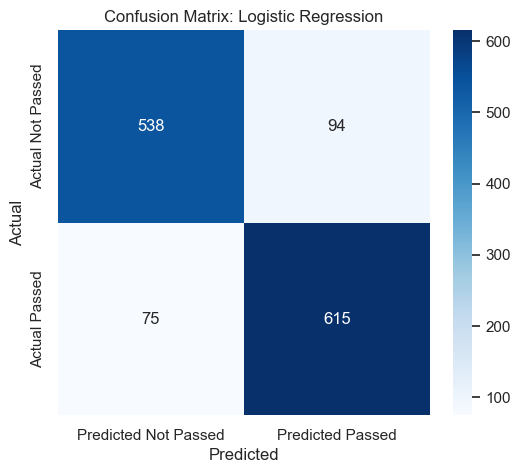

In [27]:
cm = confusion_matrix(y_test_cls, classification_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Not Passed", "Predicted Passed"],
    yticklabels=["Actual Not Passed", "Actual Passed"],
)
plt.title(f"Confusion Matrix: {best_classification_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### Classification Interpretation

I used more than accuracy because accuracy alone can hide important mistakes.

- `Precision` shows how reliable the predicted passing cases are.
- `Recall` shows how many passing students the model finds.
- `F1` balances precision and recall.
- `ROC_AUC` shows how well the model separates the two classes.

For this dataset, the classification model is useful because it predicts passing status much better than the baseline.

## 11. Feature Importance

Feature importance gives an idea of which variables the random forest used the most. This is useful for interpretation, but it should not be read as proof that one variable directly causes another.

In [28]:
rf_classifier = classification_models["Random Forest Classifier"]

if not hasattr(rf_classifier.named_steps["model"], "feature_importances_"):
    rf_classifier.fit(X_train_cls, y_train_cls)

feature_names = rf_classifier.named_steps["preprocess"].get_feature_names_out()
importances = rf_classifier.named_steps["model"].feature_importances_

importance_table = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(15)
)

importance_table

,Feature,Importance
3,numeric__Previous_Scores,0.427684
5,numeric__Study_Attendance_Index,0.153568
0,numeric__Hours_Studied,0.105033
1,numeric__Attendance,0.073148
4,numeric__Tutoring_Sessions,0.041715
2,numeric__Sleep_Hours,0.037196
6,numeric__Sleep_Distance_From_8,0.032893
17,categorical__Motivation_Level_Low,0.022174
16,categorical__Motivation_Level_High,0.020984
11,categorical__Access_to_Resources_High,0.013695


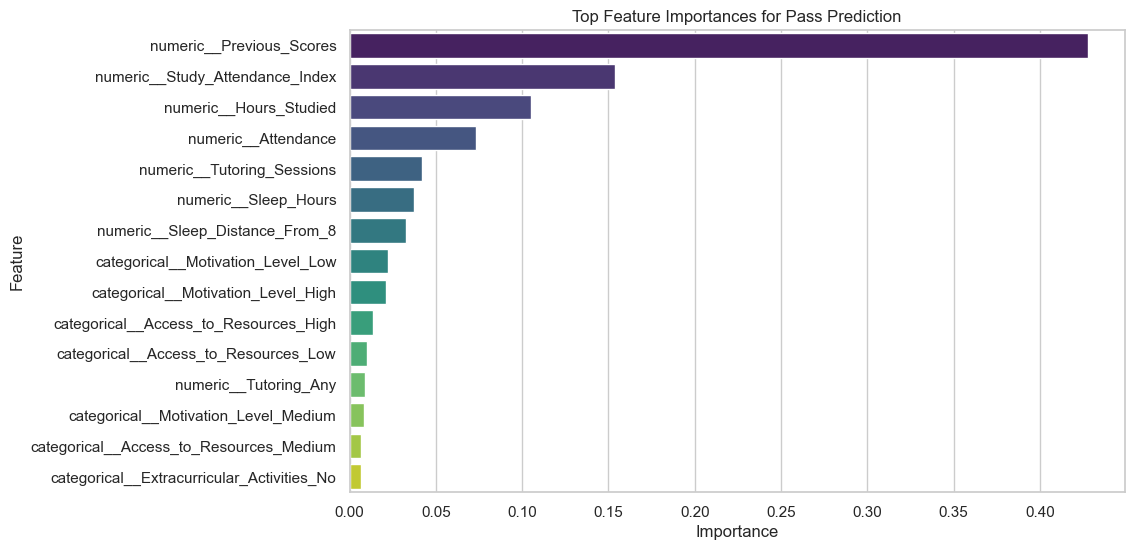

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_table, x="Importance", y="Feature", palette="viridis")
plt.title("Top Feature Importances for Pass Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 12. Final Conclusion

The dataset worked well for this machine learning unit because it allowed both clustering and prediction tasks. K-Means created student profiles, regression predicted the final exam score, and classification predicted whether a student passed.

Overall, the strongest predictors were related to previous scores, study behavior, attendance, and tutoring. The supervised models performed much better than the baselines, especially the logistic regression model for pass prediction. Before using this kind of model in a real academic setting, it would still be important to test it with new student data.